# ARES 2023-68A — Realized Monthly Time Series (simple)

Pull CDR, CPR and severity for **every reporting month** in the CLP summary
(`05/2023` deal close → `05/2026`), read straight from the file — no modelling.

| column | definition | source |
|--------|------------|--------|
| **cdr_pct** | realized annualized CDR (flow, %): `1−(1−MDR)^12` | derived from `Default %` × `Balance` |
| **default_pct** | `Default %` exactly as reported each month (stock) | CLP row `Default %` |
| **severity_pct** | `1 − Min S&P Rec Rate` = `100 − Min S&P Rec Rate` | CLP row `Min S&P Rec Rate` |
| **recovery_pct** | `Min S&P Rec Rate` | CLP row `Min S&P Rec Rate` |

**Units / suffixes:** columns ending **`_pct`** are percentages; columns ending
**`_000s`** are **thousands of USD** (the CLP `Balance (M)` label is misleading —
the row is actually in thousands, e.g. `492,061` = \$492M); `n_loans` is a count.

CPR is intentionally **not** reported: the CLP file has no prepayment field, and a
balance-based proxy is meaningless while the deal is in its reinvestment period
(prepayments are recycled into new loans). A true CPR needs the trustee
unscheduled-principal line or sequential loan tapes.

Output: tidy `realized_timeseries.csv` + a chart.


## 0 · Setup & load

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pandas", "openpyxl", "matplotlib"], check=False)
import os, glob, warnings
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40, "display.width", 200)

CANDIDATES = ["data/ARES_2023_68A", "../data/ARES_2023_68A",
              "../../data/ARES_2023_68A", "../../../data/ARES_2023_68A"]
DATA_DIR = next((p for p in CANDIDATES if os.path.isdir(p)), None)
CLP_PATH = glob.glob(os.path.join(DATA_DIR, "**", "*CLP_Summary*.xlsx"), recursive=True)[0]
print("CLP:", CLP_PATH)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


CLP: ../../data/ARES_2023_68A/ARES_2023_68A_CLP_Summary.xlsx


## 1 · Reshape CLP to month-indexed rows

Row 0 = month headers (`MM/YYYY`, newest→oldest); column 0 = metric label.
Transpose so rows = months (chronological), columns = metrics.

In [2]:
clp_raw = pd.read_excel(CLP_PATH, header=None)
months = [str(m).strip() for m in clp_raw.iloc[0, 1:]]
labels = [str(x).strip() for x in clp_raw.iloc[1:, 0]]
vals = clp_raw.iloc[1:, 1:].apply(pd.to_numeric, errors="coerce")
vals.index, vals.columns = labels, months

clp = vals.T.copy()
clp.index = pd.to_datetime(clp.index, format="%m/%Y")
clp = clp.sort_index()                    # oldest -> newest
clp.index.name = "date"
print("months:", clp.shape[0], "| range:", clp.index.min().date(), "->", clp.index.max().date())

months: 35 | range: 2023-05-01 -> 2026-05-01


## 2 · Build the realized series

Two distinct default columns:

- **`default_pct`** — the reported `Default %` **stock** (par % *currently* in default).
- **`cdr_pct`** — the realized **annualized CDR** in percent (a flow). Built the standard way:
  $$\text{MDR}_t=\frac{\text{new defaults}_t}{\text{performing balance}_{t-1}},\qquad
    \text{CDR}_t=1-(1-\text{MDR}_t)^{12}$$
  where new defaults = the positive month-over-month rise in the defaulted balance,
  and performing balance = pool balance − defaulted balance.

Dollar columns are in **thousands of USD**.

In [3]:
ts = pd.DataFrame(index=clp.index)
ts["default_pct"]   = clp["Default %"]                       # Default % stock (par % in default)
ts["recovery_pct"]  = clp["Min S&P Rec Rate"]               # %
ts["severity_pct"]  = 100.0 - clp["Min S&P Rec Rate"]       # 1 - recovery, % points
ts["wac_pct"]       = clp["WAC"]                             # %
ts["wa_margin_pct"] = clp["Weighted Average Margin"]        # %
ts["ccc_pct"]       = clp["S&P CCC+ and below %"]           # %
ts["n_loans"]       = clp["# of Loans"]                      # count
ts["balance_000s"]  = clp["Balance (M)"]                     # USD thousands ('(M)' label is misleading)

# defaulted par (stock) and the new-default flow each month (USD thousands)
ts["defaulted_bal_000s"]    = ts["default_pct"] / 100 * ts["balance_000s"]
ts["new_default_flow_000s"] = ts["defaulted_bal_000s"].diff().clip(lower=0)

# realized CDR (annualized): MDR = new defaults / beginning performing balance,
# then CDR = 1 - (1 - MDR)^12.
perf_bal  = ts["balance_000s"] - ts["defaulted_bal_000s"]    # performing balance
mdr       = ts["new_default_flow_000s"] / perf_bal.shift(1)  # monthly default rate
ts["cdr_pct"] = (1 - (1 - mdr) ** 12) * 100                  # annualized CDR, % per yr

# order: cdr_pct and default_pct first
ts = ts[["cdr_pct", "default_pct", "recovery_pct", "severity_pct", "wac_pct",
         "wa_margin_pct", "ccc_pct", "n_loans", "balance_000s",
         "defaulted_bal_000s", "new_default_flow_000s"]]
ts.round(3)

,cdr_pct,default_pct,recovery_pct,severity_pct,wac_pct,wa_margin_pct,ccc_pct,n_loans,balance_000s,defaulted_bal_000s,new_default_flow_000s
date,,,,,,,,,,,
2023-05-01,NaN,NaN,40.35,59.65,8.551,3.517,0.35,248.0,500000.0,NaN,NaN
2023-08-01,NaN,0.00,40.38,59.62,8.753,3.489,2.58,281.0,510744.0,0.000,NaN
2023-09-01,0.000,0.00,40.12,59.88,8.812,3.524,3.07,293.0,510096.0,0.000,0.000
2023-10-01,0.000,0.00,40.20,59.80,8.855,3.576,2.69,314.0,515774.0,0.000,0.000
2023-11-01,0.000,0.00,40.17,59.83,8.873,3.591,3.25,320.0,500847.0,0.000,0.000
2023-12-01,0.000,0.00,40.21,59.79,8.890,3.600,3.44,328.0,505559.0,0.000,0.000
2024-01-01,0.000,0.00,40.38,59.62,8.892,3.577,3.52,337.0,508235.0,0.000,0.000
2024-02-01,0.000,0.00,40.22,59.78,8.853,3.564,2.68,345.0,521191.0,0.000,0.000
2024-03-01,0.000,0.00,39.85,60.15,8.877,3.605,2.66,341.0,517438.0,0.000,0.000


## 3 · Export

In [4]:
ts.to_csv("realized_timeseries.csv")
print("wrote", os.path.abspath("realized_timeseries.csv"), "shape", ts.shape)

print("\nsummary:")
print(ts[["cdr_pct", "default_pct", "severity_pct", "recovery_pct"]].describe().round(3))
print(f"\nnonzero-CDR months: {(ts['cdr_pct'] > 0).sum()}  |  max monthly CDR: {ts['cdr_pct'].max():.2f}%/yr")

wrote /Users/amine/Documents/Columbia/Classes/ENGIE 4700 - Summer Project/correlation_and_tail_risk_in_clo_tranches/project/notebooks/realized_timeseries.csv shape (35, 11)

summary:
       cdr_pct  default_pct  severity_pct  recovery_pct
count   33.000       34.000        35.000        35.000
mean     0.735        0.116        61.086        38.914
std      2.552        0.271         0.917         0.917
min      0.000        0.000        59.620        37.370
25%      0.000        0.000        60.225        38.205
50%      0.000        0.000        61.370        38.630
75%      0.000        0.000        61.795        39.775
max     11.495        1.010        62.630        40.380

nonzero-CDR months: 7  |  max monthly CDR: 11.49%/yr


## 4 · Charts

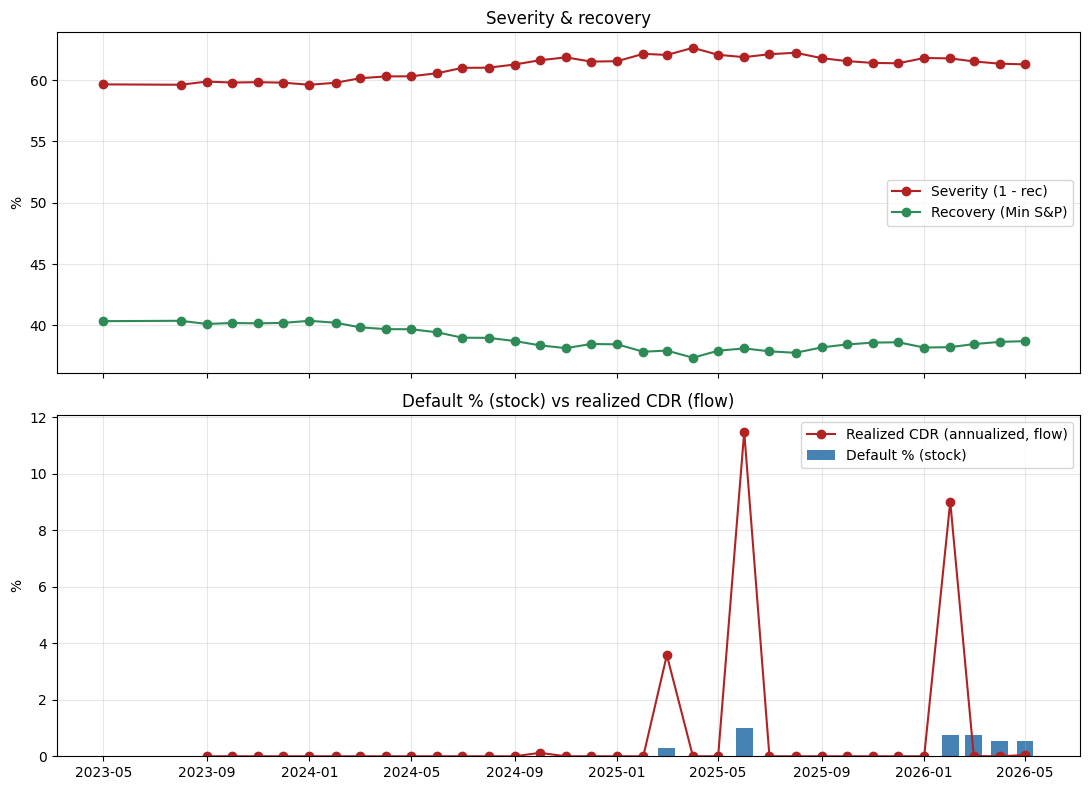

saved realized_timeseries.png


In [5]:
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

ax[0].plot(ts.index, ts["severity_pct"], "-o", color="firebrick", label="Severity (1 - rec)")
ax[0].plot(ts.index, ts["recovery_pct"], "-o", color="seagreen", label="Recovery (Min S&P)")
ax[0].set_ylabel("%"); ax[0].set_title("Severity & recovery"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].bar(ts.index, ts["default_pct"], width=20, color="steelblue", label="Default % (stock)")
ax[1].plot(ts.index, ts["cdr_pct"], "-o", color="firebrick", label="Realized CDR (annualized, flow)")
ax[1].set_ylabel("%"); ax[1].set_title("Default % (stock) vs realized CDR (flow)")
ax[1].legend(); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.savefig("realized_timeseries.png", dpi=110); plt.show()
print("saved realized_timeseries.png")

## 5 · Notes

- **`default_pct`** = `Default %` straight from the CLP file each month — a
  **stock** (par % currently in default): currently 0.55%, peaked ~1.01%, zero
  most months. (This is *not* a CDR — it's a point-in-time level.)
- **`cdr_pct`** = the realized **annualized CDR** flow in %, `1−(1−MDR)^12`, spiking only in
  the months a loan actually defaulted (zero otherwise). The deal-to-date average
  is ~0.69%/yr — **far below the stressed `2 CDR`**. It's an estimate; trustee
  new-default dollars would make it exact.
- **`defaulted_bal_000s` / `new_default_flow_000s`** are the building blocks
  (defaulted par stock, and newly-defaulted par each month, in USD thousands).
- **`severity_pct`** = `1 − Min S&P Rec Rate` ≈ 61% throughout, matching the SYT
  severity assumption of 61.
- **CPR is omitted** — the CLP file has no prepayment field and a balance-based
  proxy is meaningless during the reinvestment period (prepayments are recycled
  into new loans). A true CPR needs the trustee unscheduled-principal line or
  sequential monthly loan tapes.
